In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Global chart style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150
})

PALETTE = {
    'teal':   '#0f766e',
    'purple': '#7c3aed',
    'amber':  '#b45309',
    'red':    '#b91c1c',
    'green':  '#15803d',
    'slate':  '#475569'
}

print('Setup complete.')

Setup complete.


In [4]:
df = pd.read_csv(r'C:\Users\USER\Desktop\iot_p3\smart-garment-storage-environment-condition-monitoring-system\labeled_garment_dataset.csv', encoding='utf-8-sig')
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Total rows: {len(df):,}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print()
print('Warning level distribution:')
print(df['warning_level'].value_counts())
print()
print('Anomaly label distribution:')
print(df['anomaly_label'].value_counts())
df.head(3)

Total rows: 97,458
Columns (33): ['timestamp', 'temperature_c', 'humidity_pct', 'co2_ppm', 'pm25_ug_m3', 'pm10_ug_m3', 'tvoc_ppb', 'co_ppm', 'light_lux', 'motion_detected', 'occupancy_count', 'ventilation_status', 'dust_proxy', 'gas_proxy', 'hour_of_day', 'day_of_week', 'humidity_delta', 'dust_delta', 'gas_delta', 'humidity_pct_roll_mean', 'humidity_pct_roll_std', 'humidity_pct_z', 'dust_proxy_roll_mean', 'dust_proxy_roll_std', 'dust_proxy_z', 'gas_proxy_roll_mean', 'gas_proxy_roll_std', 'gas_proxy_z', 'anomaly_label', 'anomaly_reasons', 'risk_score', 'warning_level', 'storage_health_score']
Date range: 2024-02-18 08:00:00 → 2025-01-22 17:25:00

Warning level distribution:
warning_level
low       65923
medium    31306
high        229
Name: count, dtype: int64

Anomaly label distribution:
anomaly_label
1    87215
0    10243
Name: count, dtype: int64


,timestamp,temperature_c,humidity_pct,co2_ppm,pm25_ug_m3,pm10_ug_m3,tvoc_ppb,co_ppm,light_lux,motion_detected,...,dust_proxy_roll_std,dust_proxy_z,gas_proxy_roll_mean,gas_proxy_roll_std,gas_proxy_z,anomaly_label,anomaly_reasons,risk_score,warning_level,storage_health_score
0,2024-02-18 08:00:00,21.75,63.11,989.74,31.17,89.66,226.83,2.84,646.86,0.0,...,0.0,0.0,0.527427,0.0,0.0,0,normal,0.353202,medium,64.68
1,2024-02-18 08:05:00,27.51,68.03,924.59,27.32,44.82,116.76,3.12,845.45,1.0,...,0.0,0.0,0.527427,0.0,0.0,1,dust_jump,0.467590,medium,53.24
2,2024-02-18 08:10:00,25.32,53.51,604.05,73.84,71.08,56.59,3.59,560.03,1.0,...,0.0,0.0,0.527427,0.0,0.0,1,humidity_jump|dust_jump|gas_jump,0.335721,medium,66.43


In [5]:
ANOMALY_FEATURES = [
    'temperature_c', 'humidity_pct', 'light_lux', 'dust_proxy', 'gas_proxy',
    'humidity_delta', 'dust_delta', 'gas_delta',
    'humidity_pct_z', 'dust_proxy_z', 'gas_proxy_z',
    'humidity_pct_roll_std', 'dust_proxy_roll_std', 'gas_proxy_roll_std',
    'hour_of_day', 'day_of_week'
]

WARNING_FEATURES = ANOMALY_FEATURES + [
    'humidity_pct_roll_mean', 'dust_proxy_roll_mean', 'gas_proxy_roll_mean',
    'anomaly_score_from_pipeline', 'anomaly_flag_from_pipeline'
]

CORR_FEATURES = [
    'temperature_c', 'humidity_pct', 'light_lux', 'dust_proxy', 'gas_proxy',
    'humidity_delta', 'dust_delta', 'gas_delta',
    'humidity_pct_z', 'dust_proxy_z', 'gas_proxy_z',
    'humidity_pct_roll_mean', 'dust_proxy_roll_mean', 'gas_proxy_roll_mean',
    'humidity_pct_roll_std', 'dust_proxy_roll_std', 'gas_proxy_roll_std',
    'anomaly_label'
]

# Drop rows with missing features
df_clean = df.dropna(subset=ANOMALY_FEATURES + ['anomaly_label', 'warning_level']).copy()

# Encode warning level for correlation
wl_map = {'low': 0, 'medium': 1, 'high': 2}
df_clean['warning_level_num'] = df_clean['warning_level'].map(wl_map)

# Chronological split: 70% train, 15% val, 15% test
n = len(df_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df_clean.iloc[:train_end].copy()
df_val   = df_clean.iloc[train_end:val_end].copy()
df_test  = df_clean.iloc[val_end:].copy()

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

Train: 68,220 | Val: 14,619 | Test: 14,619


## CHART 1 : Class Distribution (Warning Level & Anomaly Label)



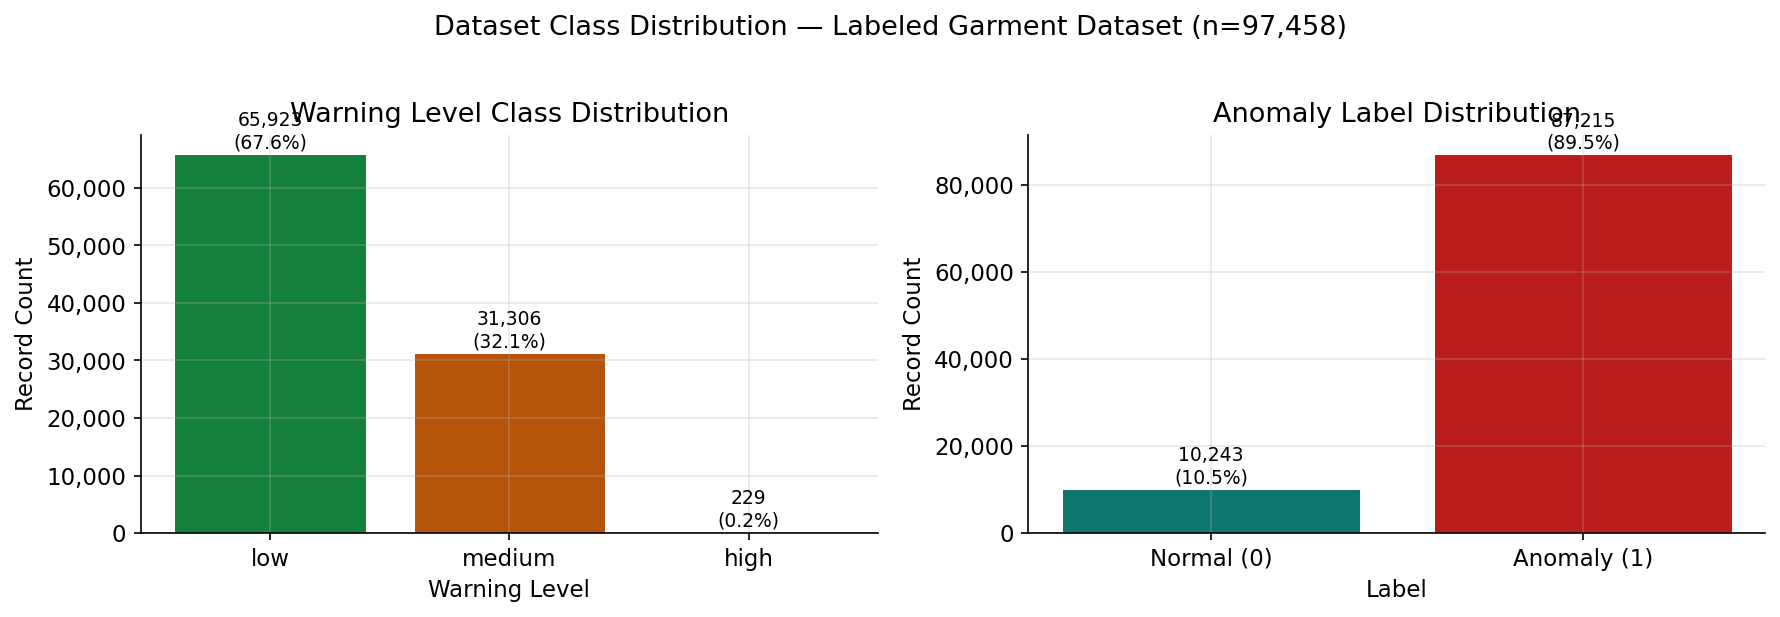

Saved: chart1_class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Warning level distribution
wl_counts = df_clean['warning_level'].value_counts().reindex(['low','medium','high'])
colors_wl = [PALETTE['green'], PALETTE['amber'], PALETTE['red']]
bars = axes[0].bar(wl_counts.index, wl_counts.values, color=colors_wl, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, wl_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Warning Level Class Distribution')
axes[0].set_xlabel('Warning Level')
axes[0].set_ylabel('Record Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Anomaly label distribution
al_counts = df_clean['anomaly_label'].value_counts().sort_index()
al_labels = ['Normal (0)', 'Anomaly (1)']
al_colors = [PALETTE['teal'], PALETTE['red']]
bars2 = axes[1].bar(al_labels, al_counts.values, color=al_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, al_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Anomaly Label Distribution')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Record Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Dataset Class Distribution — Labeled Garment Dataset (n=97,458)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('chart1_class_distribution.png')
plt.show()
print('Saved: chart1_class_distribution.png')